# 11: The Crystal

Empirical notebook for the substrate-first crystal: axial hex coordinates, six-neighbor topology, irreversible local growth, damage, defects, and collision ancestry.


In [1]:
from pathlib import Path
import base64
import copy
import math
import sqlite3
from collections import Counter, defaultdict, deque
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
BOOK_FIG_DIR = ROOT / "static" / "images" / "books" / "digital-life"
FIG_DIR = ROOT / "notebooks" / "generated-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180


In [2]:
HEX_DIRECTIONS = ((1,0),(1,-1),(0,-1),(-1,0),(-1,1),(0,1))

def neighbors(cell):
    q, r = cell
    for dq, dr in HEX_DIRECTIONS:
        yield q + dq, r + dr

def hex_distance(cell, origin=(0,0)):
    q, r = cell; oq, or_ = origin
    x, z = q - oq, r - or_
    y = -x - z
    return max(abs(x), abs(y), abs(z))

def axial_to_xy(cell):
    q, r = cell
    return (math.sqrt(3) * (q + r / 2), 1.5 * r)

def grow_once(occupied, blocked=None, min_neighbors=1):
    blocked = blocked or set()
    counts = Counter()
    for cell in occupied:
        for nxt in neighbors(cell):
            if nxt not in occupied and nxt not in blocked:
                counts[nxt] += 1
    return set(occupied) | {cell for cell, count in counts.items() if count >= min_neighbors}

def run_growth(generations, seeds=((0,0),), blocked=None):
    occupied = set(seeds)
    history = [set(occupied)]
    for _ in range(generations):
        occupied = grow_once(occupied, blocked=blocked)
        history.append(set(occupied))
    return history

def theoretical_hex_ball(r):
    return 1 + 3 * r * (r + 1)

def draw_hex_points(cells, title, ax=None, color=None):
    ax = ax or plt.gca()
    pts = np.array([axial_to_xy(c) for c in cells]) if cells else np.empty((0,2))
    if len(pts):
        ax.scatter(pts[:,0], pts[:,1], marker="h", s=80, c=color)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.axis("off")
    return ax


In [3]:
EXPERIMENT = {"seed": [(0,0)], "growth_generations": 40, "damage_growth": 15, "damage_center": (2,-1), "damage_radius": 2, "refill_steps": 5, "collision_seeds": {"A": (-9,0), "B": (9,0)}, "collision_generations": 16}
EXPERIMENT


{'seed': [(0, 0)],
 'growth_generations': 40,
 'damage_growth': 15,
 'damage_center': (2, -1),
 'damage_radius': 2,
 'refill_steps': 5,
 'collision_seeds': {'A': (-9, 0), 'B': (9, 0)},
 'collision_generations': 16}

## Grow from one seed and verify the hexagonal-ball law


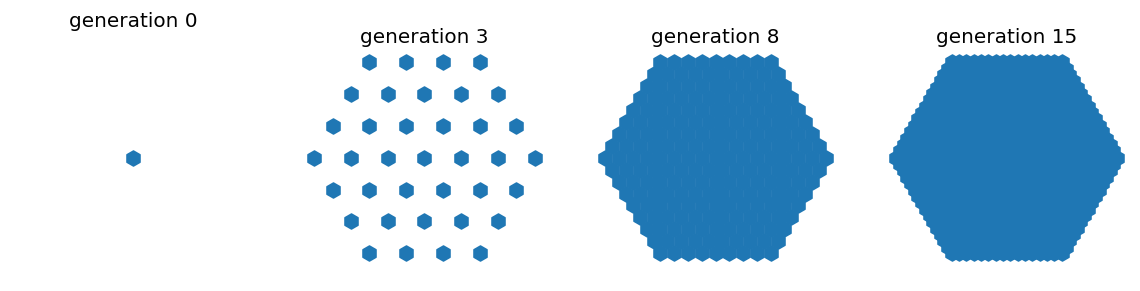

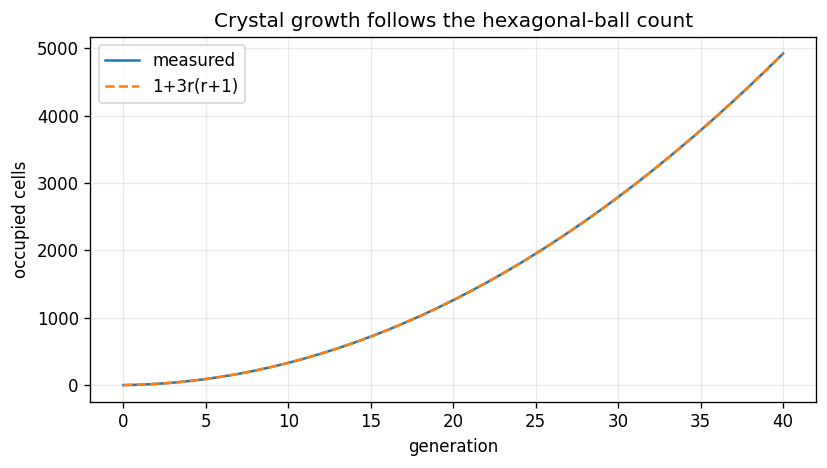

{'r0': 1, 'r4': 61, 'r40': 4921}

In [4]:
history = run_growth(EXPERIMENT["growth_generations"])
measured = np.array([len(s) for s in history]); r = np.arange(len(history)); theory = np.array([theoretical_hex_ball(int(x)) for x in r])
assert np.array_equal(measured, theory)
fig, axes = plt.subplots(1,4,figsize=(12,3));
for ax,t in zip(axes,[0,3,8,15]): draw_hex_points(history[t], f"generation {t}", ax=ax)
plt.show()
fig, ax = plt.subplots(figsize=(7,4)); ax.plot(r, measured, label="measured"); ax.plot(r, theory, "--", label="1+3r(r+1)"); ax.set(title="Crystal growth follows the hexagonal-ball count", xlabel="generation", ylabel="occupied cells"); ax.legend(); ax.grid(alpha=.25); fig.tight_layout(); fig.savefig(FIG_DIR / "ch11-crystal-growth-curve.png", bbox_inches="tight"); plt.show()
{"r0": int(measured[0]), "r4": int(measured[4]), "r40": int(measured[40])}


## Damage experiment: hole filling by ordinary growth


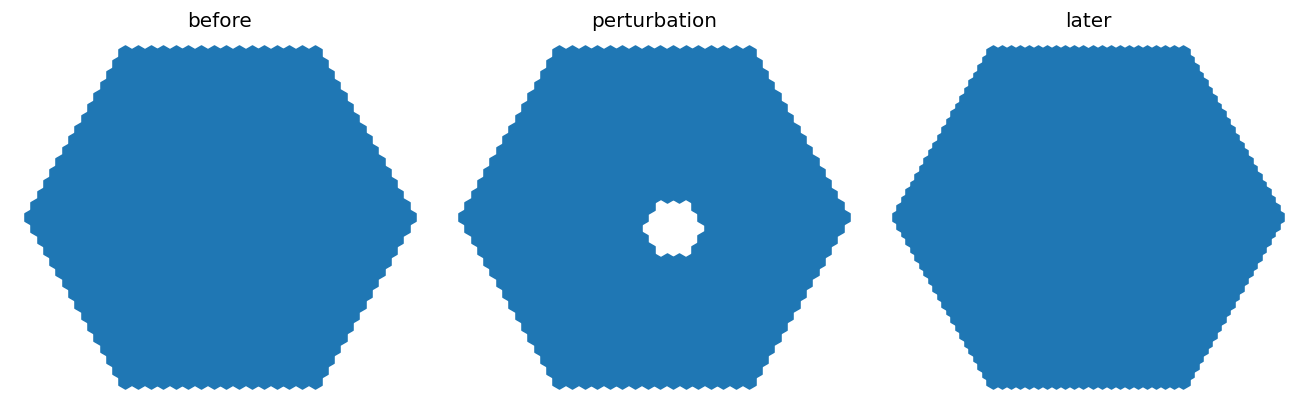

[0.0, 0.631578947368421, 0.9473684210526315, 1.0, 1.0, 1.0]

In [5]:
before = run_growth(EXPERIMENT["damage_growth"])[-1]
damage = {c for c in before if hex_distance(c, EXPERIMENT["damage_center"]) <= EXPERIMENT["damage_radius"]}
damaged = before - damage
later = set(damaged)
refill=[]
for step_i in range(EXPERIMENT["refill_steps"] + 1):
    refill.append(len(damage & later) / len(damage))
    later = grow_once(later)
fig, axes = plt.subplots(1,3,figsize=(11,3.5));
for ax,title,cells in zip(axes,["before","perturbation","later"],[before, damaged, later]): draw_hex_points(cells,title,ax=ax)
fig.tight_layout(); fig.savefig(FIG_DIR / "ch11-crystal-damage-triptych.png", bbox_inches="tight"); plt.show()
refill


## Defects: persistent blocked sites leave structural traces


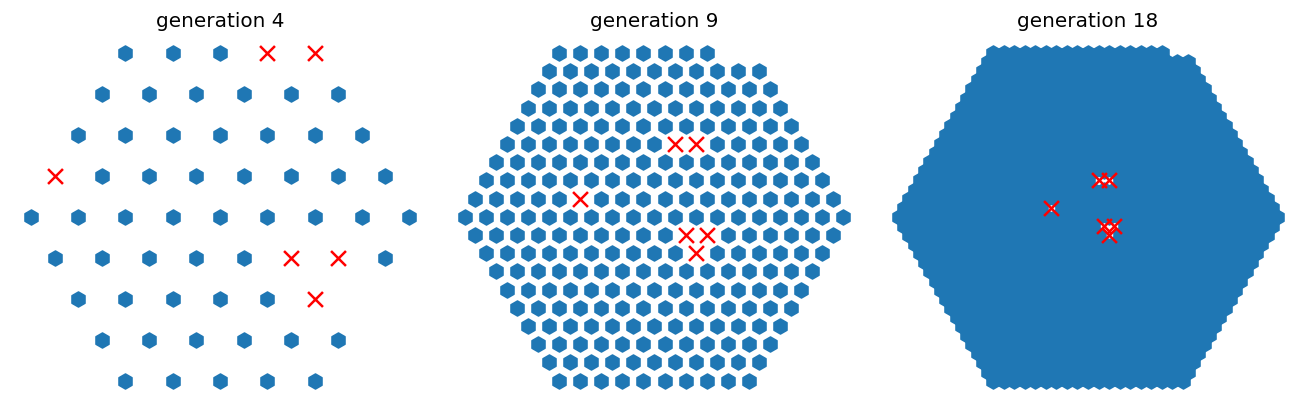

{'blocked_sites': 6, 'occupied_after_18': 1019}

In [6]:
blocked = {(2,-1),(3,-1),(3,-2),(0,4),(-1,4),(-4,1)}
def_hist = run_growth(18, blocked=blocked)
fig, axes = plt.subplots(1,3,figsize=(11,3.5));
for ax,t in zip(axes,[4,9,18]):
    draw_hex_points(def_hist[t], f"generation {t}", ax=ax); pts=np.array([axial_to_xy(c) for c in blocked]); ax.scatter(pts[:,0], pts[:,1], marker="x", c="red", s=80)
fig.tight_layout(); fig.savefig(FIG_DIR / "ch11-crystal-defects.png", bbox_inches="tight"); plt.show()
{"blocked_sites": len(blocked), "occupied_after_18": len(def_hist[-1])}


## Collision: state view versus provenance view


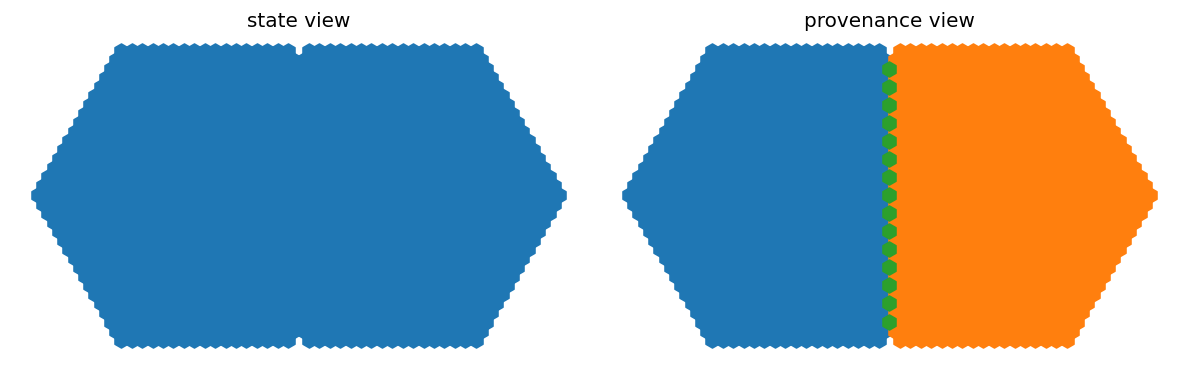

Counter({'A': 697, 'B': 697, 'M': 15})

In [7]:
def collision_step(state, seeds, t):
    proposals=defaultdict(set)
    for cell, owner in state.items():
        for nxt in neighbors(cell):
            if nxt not in state: proposals[nxt].add(owner)
    out=dict(state)
    for cell, owners in proposals.items():
        if len(owners)==1: out[cell]=next(iter(owners))
        else: out[cell]="M"
    return out
seeds=EXPERIMENT["collision_seeds"]; state={tuple(v):k for k,v in seeds.items()}
for t in range(EXPERIMENT["collision_generations"]): state=collision_step(state, seeds, t+1)
fig, axes = plt.subplots(1,2,figsize=(10,4)); draw_hex_points(set(state), "state view", ax=axes[0]);
for owner,color in [("A","tab:blue"),("B","tab:orange"),("M","tab:green")]: draw_hex_points({c for c,o in state.items() if o==owner}, owner, ax=axes[1], color=color)
axes[1].set_title("provenance view"); fig.tight_layout(); fig.savefig(FIG_DIR / "ch11-crystal-collision-ancestry.png", bbox_inches="tight"); plt.show()
Counter(state.values())


## Bounded conclusion

The crystal empirically supports ordered irreversible growth, exact agreement with the hexagonal-ball law, ordinary growth into holes, persistent defects from blocked sites, and provenance/history distinctions in collisions. It does not demonstrate regeneration, memory, individuality, reproduction, adaptation, or life.

## Provenance

**Book chapter**: `content/books/digital-life/11-the-crystal/index.md`

**Research scripts used**: `scripts/books/digital-life/ch11_the_crystal.py`

**Book figures reproduced as notebook figures/frames**: growth curve, damage triptych, defects, collision ancestry. GIFs are represented by selected inline frames to keep execution light.
